# Customer Churn Prediction Using Machine Learning

## Objective

The objective of this project is to analyze customer churn behavior and build machine learning models to predict whether a customer is likely to churn. The project includes data cleaning, exploratory data analysis, feature engineering, model building, evaluation, and business recommendations.

# Data Loading

In [1]:
import pandas as pd

df = pd.read_csv("Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Data Cleaning and Preprocessing

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
customerID          7043 non-null object
gender              7043 non-null object
SeniorCitizen       7043 non-null int64
Partner             7043 non-null object
Dependents          7043 non-null object
tenure              7043 non-null int64
PhoneService        7043 non-null object
MultipleLines       7043 non-null object
InternetService     7043 non-null object
OnlineSecurity      7043 non-null object
OnlineBackup        7043 non-null object
DeviceProtection    7043 non-null object
TechSupport         7043 non-null object
StreamingTV         7043 non-null object
StreamingMovies     7043 non-null object
Contract            7043 non-null object
PaperlessBilling    7043 non-null object
PaymentMethod       7043 non-null object
MonthlyCharges      7043 non-null float64
TotalCharges        7043 non-null object
Churn               7043 non-null object
dtypes: float64(1), int64(2), obj

In [3]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [4]:
df['TotalCharges'].head()

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: object

In [5]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [6]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [7]:
df['TotalCharges'].fillna(
    df['TotalCharges'].median(),
    inplace=True
)

In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Exploratory Data Analysis

In [9]:
(df['Churn'].value_counts(normalize=True)*100).round(2)

No     73.46
Yes    26.54
Name: Churn, dtype: float64

In [10]:
pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
)*100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

plt.title("Contract Type vs Churn")
plt.show()

<Figure size 640x480 with 1 Axes>

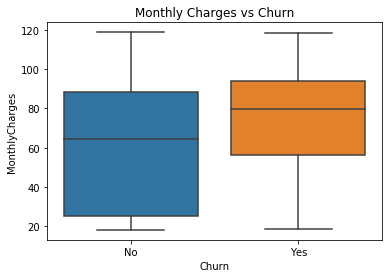

In [12]:
sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.title("Monthly Charges vs Churn")
plt.show()

In [13]:
df.drop('customerID', axis=1, inplace=True)

In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# Correlation Analysis

In [15]:
corr = df.corr()

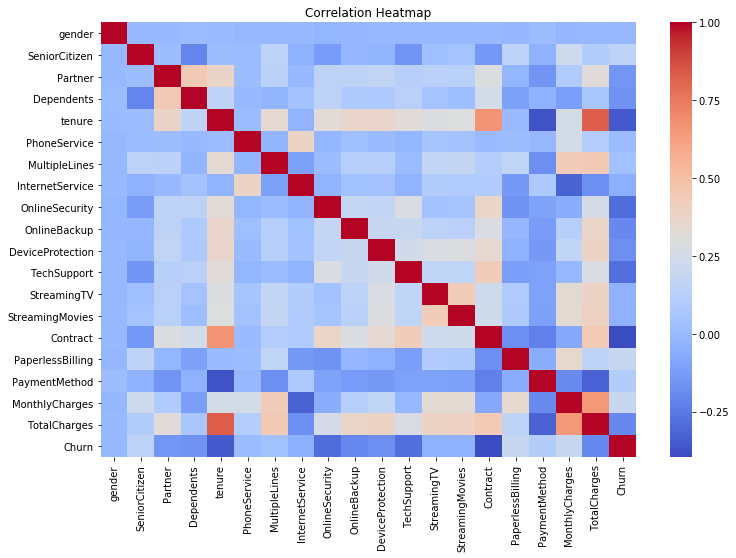

In [16]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [17]:
corr['Churn'].sort_values(ascending=False)

Churn               1.000000
MonthlyCharges      0.193356
PaperlessBilling    0.191825
SeniorCitizen       0.150889
PaymentMethod       0.107062
MultipleLines       0.038037
PhoneService        0.011942
gender             -0.008612
StreamingTV        -0.036581
StreamingMovies    -0.038492
InternetService    -0.047291
Partner            -0.150448
Dependents         -0.164221
DeviceProtection   -0.178134
OnlineBackup       -0.195525
TotalCharges       -0.199037
TechSupport        -0.282492
OnlineSecurity     -0.289309
tenure             -0.352229
Contract           -0.396713
Name: Churn, dtype: float64

# Model Building

In [18]:
X = df.drop('Churn', axis=1)

y = df['Churn']

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

C:\Users\DELL\Anaconda2\lib\site-packages\sklearn\preprocessing\data.py:645: DataConversionWarning: Data with input dtype int32, int64, float64 were all converted to float64 by StandardScaler.
  return self.partial_fit(X, y)
C:\Users\DELL\Anaconda2\lib\site-packages\sklearn\base.py:464: DataConversionWarning: Data with input dtype int32, int64, float64 were all converted to float64 by StandardScaler.
  return self.fit(X, **fit_params).transform(X)


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

C:\Users\DELL\Anaconda2\lib\site-packages\sklearn\linear_model\logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)


# Model Evaluation

In [22]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Accuracy:", accuracy_score(y_test,y_pred_lr))
print("Precision:", precision_score(y_test,y_pred_lr))
print("Recall:", recall_score(y_test,y_pred_lr))
print("F1 Score:", f1_score(y_test,y_pred_lr))

('Accuracy:', 0.8161816891412349)
('Precision:', 0.678125)
('Recall:', 0.5817694369973191)
('F1 Score:', 0.6262626262626263)


In [23]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test,y_pred_lr)

array([[933, 103],
       [156, 217]], dtype=int64)

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train,y_train)

y_pred_rf = rf.predict(X_test)

C:\Users\DELL\Anaconda2\lib\site-packages\sklearn\ensemble\forest.py:246: FutureWarning: The default value of n_estimators will change from 10 in version 0.20 to 100 in 0.22.
  "10 in version 0.20 to 100 in 0.22.", FutureWarning)


In [25]:
print("Accuracy:", accuracy_score(y_test,y_pred_rf))
print("Precision:", precision_score(y_test,y_pred_rf))
print("Recall:", recall_score(y_test,y_pred_rf))
print("F1 Score:", f1_score(y_test,y_pred_rf))

('Accuracy:', 0.7806955287437899)
('Precision:', 0.6176470588235294)
('Recall:', 0.450402144772118)
('F1 Score:', 0.5209302325581395)


In [26]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test,y_pred_rf)

array([[932, 104],
       [205, 168]], dtype=int64)

In [27]:
comparison = pd.DataFrame({
    'Model':['Logistic Regression','Random Forest'],
    'Accuracy':[81.62,78.07],
    'Precision':[67.81,61.76],
    'Recall':[58.17,45.04],
    'F1 Score':[62.63,52.09]
})

comparison

,Accuracy,F1 Score,Model,Precision,Recall
0,81.62,62.63,Logistic Regression,67.81,58.17
1,78.07,52.09,Random Forest,61.76,45.04


# Model Comparison

Logistic Regression performed better than Random Forest across all evaluation metrics.

Logistic Regression:
- Accuracy: 81.62%
- Precision: 67.81%
- Recall: 58.17%
- F1 Score: 62.63%

Random Forest:
- Accuracy: 78.07%
- Precision: 61.76%
- Recall: 45.04%
- F1 Score: 52.09%

Therefore, Logistic Regression was selected as the final model.

# Business Recommendations

1. Promote one-year and two-year contracts through incentives.

2. Offer retention discounts to customers with high monthly charges.

3. Encourage adoption of Online Security and Tech Support services.

4. Focus retention campaigns on customers with low tenure and month-to-month contracts.

# Conclusion

Customer churn prediction was performed using Logistic Regression and Random Forest models.

Exploratory Data Analysis showed that contract type, tenure, monthly charges, online security, and tech support significantly influence churn behavior.

Logistic Regression achieved the best performance with an accuracy of 81.62% and was selected as the final churn prediction model.